# Solving an Inverse Projectile Problem with a Genetic Algorithm

## Objective

In this assignment you will implement a **Genetic Algorithm (GA)** with **binary encoding** to solve an inverse projectile problem. The goal is to determine the launch parameters of a **cannon-like launcher** so that a projectile reaches a desired horizontal distance.

You will work with:

- binary encoding of continuous variables  
- chromosome decoding  
- fitness function design  
- experimentation with GA parameters  
- interactive visualization using `ipywidgets`

Cells labeled **Student Task** require you to implement or modify code.  
Cells without this label contain code that has already been provided.

---

# Problem Description

### Rescue Capsule Launch System

In a mountainous region, a mechanical launcher has been installed to deliver **capsules containing medical supplies** to an isolated community.

The system uses a launching mechanism that accelerates a capsule of mass $m$ along a launch tube.

The launcher applies a **constant force $F$** on the capsule while it travels inside a tube of length $L$. When the capsule exits the tube, it leaves the launcher with an initial velocity $v_0$ forming an angle $\theta$ with respect to the horizontal.

After leaving the launcher, the capsule follows a **projectile trajectory** under the influence of gravity alone (air resistance is neglected).

---

## Projectile Motion Model

The initial velocity generated by the launcher is determined from the **work–energy principle**:

$$
v_0 = \sqrt{\frac{2FL}{m}}
$$

If the projectile is fired at an angle $\theta$ relative to the horizontal, the **horizontal landing range** of the projectile is

$$
R_l = \frac{v_0^2 \sin(2\theta)}{g}
$$

where

$$
g = 9.81\ \text{m/s}^2
$$

---

## Maximum Height of the Projectile

The maximum height reached by the projectile during its trajectory is given by

$$
h_{max} = \frac{v_0^2 \sin^2(\theta)}{2g}
$$

This value represents the highest vertical position reached before the projectile begins to descend.

---

## Inverse Problem

Instead of computing the range from the launch parameters, you must solve the **inverse problem**:

> Given a target horizontal distance (goal range) $R_g$ and a projectile mass $m$, use a Genetic Algorithm to determine the values of $L$, $\theta$, and $F$ that produce a landing range $R_l$ as close as possible to $R_g$.

---

# Parameter and Objective Constraints 

The parameters must satisfy the following ranges:

$$
L \in [1,\ 20]\ \text{m}
$$

$$
F \in [500,\ 5000]\ \text{N}
$$

$$
\theta \in [10^\circ,\ 80^\circ]
$$

The target distance must satisfy

$$
R_g \in [100,\ 2000]
$$

The projectile mass will be fixed at

$$
m = 10\ \text{kg}
$$

---

# Notebook Structure and Tasks

The following sections correspond to the cells in this notebook.

When a section is marked **Student Task**, you must implement or modify the code in the corresponding cell.

---

## 1. Constants Definition

**Student Task**

Define the constants required for the problem, such as:

- gravitational acceleration $g$
- projectile mass $m$
- maximum plotting range
- parameter bounds

---

## 2. Chromosome Decoding Functions

**Student Task**

Implement the functions that decode a binary chromosome into the real-valued parameters:

- $L$
- $\theta$
- $F$

Use the decoding formula:

$$
x = x_{min} + \frac{integer}{2^n - 1}(x_{max} - x_{min})
$$

Your decoding function should:

- extract the binary segments corresponding to each variable
- convert them to integers
- map them to their corresponding real intervals

---

## 3. Distance Function

**Student Task**

Implement the function that computes the **landing range** $R_l$ of the projectile using the physical model described earlier.

Your function should compute:

- initial velocity $v_0$
- landing range $R_l$

---

## 4. Goal Range Drawing

The notebook includes a function that draws:

- the launcher position
- the target location $R_g$
- the projectile trajectory

This code has already been provided.

---

## 5. Fitness Function

**Student Task**

Define the **fitness function** that evaluates how close the projectile landing range is to the target range.

Possible definitions include:

$$
error = |R_g - R_l|
$$

or

$$
error = (R_g - R_l)^2
$$

The goal of the Genetic Algorithm is to **minimize this error**.

---

## 6. GA Definition

**Student Task**

Define the main components of the Genetic Algorithm:

- fitness function registration
- gene generation
- individual representation
- population generation

These definitions determine how candidate solutions are represented and evaluated.

---

## 7. Single Experiment Runner

This section contains code that runs **a single Genetic Algorithm experiment** using a fixed set of parameters.

The code has already been provided.

---

## 8. Multiple Experiments Runner

This section contains code that runs **multiple GA experiments automatically** to analyze algorithm performance.

The code has already been provided.

---

## 9. Target Distance Selection Interface

The notebook includes an **interactive interface using `ipywidgets`** that allows the user to select the goal distance $R_g$.

The interface also visualizes the resulting projectile trajectory.

This code has already been provided.

---

## 10. Fixed Parameters Experiment

**Student Task**

Run an experiment with a fixed set of GA parameters and analyze the result.

Observe:

- convergence behavior
- final solution quality

---

## 11. Mutation Probability Experiments

**Student Task**

Run experiments varying the **mutation probability** and analyze how it affects:

- convergence speed
- stability of solutions
- final accuracy

---

## 12. Crossover Probability Experiments

**Student Task**

Run experiments varying the **crossover probability** and analyze its impact on the GA performance.

---

## 13. Population Size Experiments

**Student Task**

Run experiments varying the **population size**.

Discuss how population size affects:

- exploration of the search space
- convergence speed
- solution quality

---

## 14. Discussion and Conclusions

**Student Task**

Summarize your observations from the experiments.

Discuss:

- the best solutions found
- the difference between $R_g$ and $R_l$
- the influence of GA parameters
- the stability of the algorithm across runs

Note that **multiple combinations of parameters may produce similar projectile ranges**.  
Discuss how this affects the behavior of the Genetic Algorithm.

---

# Deliverables

Submit this **Jupyter Notebook** with all **Student Task sections completed**, including:

- implemented functions
- experimental results
- discussion and conclusions



In [4]:
import sys
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import math
import ipywidgets as widgets
from IPython.display import display, clear_output

from deap import base, creator, tools, algorithms

sys.path.append("..")
from common.homtransf import *
from common.robot_2D import *

### 1 Constants definition <span style="color:blue"><b>(Student task)</b></span>
Define the following constants from the problem statement.


In [5]:
# =========================================================
# CONSTANTS
# =========================================================

# Tube / barrel length bounds (m)
MIN_LENGHT = 1.0
MAX_LENGHT = 20.0
N_BITS_LENGTH = 10

# Launch force bounds (N)
MIN_FORCE = 500.0
MAX_FORCE = 5000.0
N_BITS_FORCE = 10

# Launch angle bounds (converted to radians)
MIN_THETA = math.radians(10)   # Must be in radians
MAX_THETA = math.radians(80)   # Must be in radians
N_BITS_THETA = 10

TOTAL_BITS = N_BITS_LENGTH + N_BITS_FORCE + N_BITS_THETA

# Target range bounds (m)
MIN_R = 100.0
MAX_R = 2000.0

# Physical constants
MASS = 10.0         # kg
G    = 9.81         # Gravity acceleration in m/s^2

print(f"Total chromosome length : {TOTAL_BITS} bits")
print(f"L   : [{MIN_LENGHT}, {MAX_LENGHT}] m")
print(f"F   : [{MIN_FORCE}, {MAX_FORCE}] N")
print(f"θ   : [{math.degrees(MIN_THETA):.0f}°, {math.degrees(MAX_THETA):.0f}°]")
print(f"Rg  : [{MIN_R}, {MAX_R}] m")
print(f"m   : {MASS} kg,  g : {G} m/s²")


Total chromosome length : 30 bits
L   : [1.0, 20.0] m
F   : [500.0, 5000.0] N
θ   : [10°, 80°]
Rg  : [100.0, 2000.0] m
m   : 10.0 kg,  g : 9.81 m/s²


<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 2. Chromosome decoding functions <span style="color:blue"><b>(Student task)</b></span>
Insert an image representing the cromossoma decoding functions and implement the decoding functions, then erase this coment. 
<div style="text-align:center;">
    <img src="../images/step.png" style="height:380px; width:auto;">
</div>
</div>

In [6]:
def bits_decoding(bits, x_min, x_max):

    n = len(bits)

    # Convert the binary list to an integer
    integer = int("".join(map(str, bits)), 2)

    # Linearly scale the integer to the interval [x_min, x_max]
    value = x_min + (integer / (2**n - 1)) * (x_max - x_min)

    return value


def bits_to_angle(bits):
    theta = bits_decoding(bits, MIN_THETA, MAX_THETA)
    return theta


def bits_to_length(bits):
    length = bits_decoding(bits, MIN_LENGHT, MAX_LENGHT)
    return length


def bits_to_force(bits):
    force = bits_decoding(bits, MIN_FORCE, MAX_FORCE)
    return force


def decode_individual(individual):

    # Extract the first N_BITS_LENGTH bits for length
    length_bits = individual[:N_BITS_LENGTH]

    # Extract the next N_BITS_FORCE bits for force
    force_bits  = individual[N_BITS_LENGTH : (N_BITS_LENGTH + N_BITS_FORCE)]

    # Extract the remaining bits for theta
    theta_bits  = individual[(N_BITS_LENGTH + N_BITS_FORCE):]

    # Convert each segment to its real-valued parameter
    length = bits_to_length(length_bits)
    force  = bits_to_force(force_bits)
    theta  = bits_to_angle(theta_bits)

    return length, force, theta


<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 3. Distance function <span style="color:blue"><b>(Student task)</b></span>
Insert an image representing the distance function and implement it, then erase this coment. 

<div style="text-align:center;">
    <img src="../images/step.png" style="height:400px; width:auto;">
</div>
</div>


In [7]:
def distance(r_g, r_l):
    distance = abs(r_g - r_l)
    return distance


### 4. Goal Range Drawing

In [8]:
def _setup_range_plot(r_g, y_max, title):
    """
    Creates the common plot structure:
    - launch point at (0, 0)
    - target at (r_g, 0)
    - fixed x-axis up to MAX_R
    """
    y_max = y_max * 0.1

    plt.figure(figsize=(8, 5))

    # Launch point
    plt.scatter(0, 0, s=120)
    plt.text(0, -0.05 * y_max, "Launch (0,0)", ha="center")

    # Target
    plt.scatter(r_g, 0, s=150)
    plt.text(r_g, 0, "X", fontsize=22, ha="center", va="center")
    plt.text(r_g, -0.1 * y_max, f"Target ({r_g:.2f}, 0)", ha="center")

    # Axes
    plt.xlim(0, MAX_R)
    plt.ylim(0, y_max)

    plt.xlabel("x (distance)")
    plt.ylabel("y (height)")
    plt.title(title)

    plt.axhline(0)
    plt.axvline(0)
    plt.grid(True)


def draw_target(R, y_max):
    """
    Draws only the launch point and the target.
    """
    _setup_range_plot(R, y_max, "Launch Point and Target")
    plt.show()


def draw_solution(r_g, r_landing, f, theta, l, m=MASS, g=G, n_points=300):
    """
    Draws the target at (r_g, 0) and the projectile trajectory
    produced by parameters f, theta, and l, ending at (r_landing, 0).

    Parameters
    ----------
    r_g : float
        Target horizontal distance.
    r_landing : float
        Landing distance reached by the solution.
    f : float
        Applied force.
    theta : float
        Launch angle in radians.
    l : float
        Launch tube / barrel length.
    m : float
        Projectile mass.
    g : float
        Gravity.
    n_points : int
        Number of points used to draw the parabola.
    """

    # Initial velocity from work-energy relation
    v0 = math.sqrt((2 * f * l) / m)

    # Time of flight assuming launch and landing at same height
    t_flight = (2 * v0 * math.sin(theta)) / g

    # Trajectory
    t = np.linspace(0, t_flight, n_points)
    x = v0 * math.cos(theta) * t
    y = v0 * math.sin(theta) * t - 0.5 * g * t**2

    # Theoretical maximum height for scaling
    y_peak = (v0**2 * math.sin(theta)**2) / (2 * g)

    # Use the larger of:
    # - the trajectory peak
    # - a fraction of MAX_R so small trajectories still look good
    y_max_for_plot = max(y_peak * 1.25, MAX_R * 0.25)

    _setup_range_plot(r_g, y_max_for_plot / 0.1, "Projectile Solution")

    # Parabolic trajectory
    plt.plot(x, y, linewidth=2, label="Trajectory")

    # Landing point
    plt.scatter(r_landing, 0, s=100)
    plt.text(r_landing, 0.08 * (y_max_for_plot), f"Landing ({r_landing:.2f}, 0)", ha="center")

    # Optional visual aid: vertical line at landing point
    plt.axvline(r_landing, linestyle="--", alpha=0.7)

    # Show solution parameters
    info = (
        f"F = {f:.2f} N\n"
        f"Theta = {theta:.3f} rad\n"
        f"L = {l:.2f} m\n"
        f"R_goal = {r_g:.2f} m\n"
        f"R_landing = {r_landing:.2f} m\n"
        f"Error = {abs(r_g - r_landing):.2f} m"
    )

    plt.text(
        MAX_R * 0.68,
        y_max_for_plot * 0.95,
        info,
        va="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    plt.legend()
    plt.show()

### 5. Define the fitness function <span style="color:blue"><b>(Student task)</b></span>
- Define the function `compute_r_landing(length, force, theta, m=MASS, g=G)` that computes $r_l$ given $lenght$ (L), $force$ (F) and $\theta$
- Using the decoding function `decode_individual(individual)` and `compute_r_landing(length, force, theta, m=MASS, g=G)` implement fitness function.

In [9]:
# =========================================================
# 1. FITNESS FUNCTION
# =========================================================

def compute_r_landing(length, force, theta, m=MASS, g=G):
    # Initial velocity from the work-energy relation: v0 = sqrt(2*F*L/m)
    v0  = math.sqrt((2 * force * length) / m)

    # Horizontal range from projectile kinematics: R_l = v0^2 * sin(2θ) / g
    r_l = (v0**2 * math.sin(2 * theta)) / g

    return r_l


def eval_function(individual):
    global r_g

    # Decode the individual's binary representation into parameters
    length, force, theta = decode_individual(individual)

    # Compute the landing range with the decoded parameters
    r_l = compute_r_landing(length, force, theta)

    # Compute the error between the landing range and the goal range
    dist = distance(r_g, r_l)

    return (dist,)


<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 6. GA definition: fitness, gene, individual, population <span style="color:blue"><b>(Student task)</b></span>

<div style="text-align:center;">
    <img src="../images/GA_Toolbox.png" style="height:400px; width:auto;">
</div>
</div>

In [11]:
# =========================================================
# 2. CREATE DEAP CLASSES (Only once per Python session)
# =========================================================
# DEAP dynamically creates classes for individuals and fitness.
# We check first to avoid errors if the notebook cell is run multiple times.

if not hasattr(creator, "fitness"):
    creator.create("fitness", base.Fitness, weights=(-1.0,)) # weights=(-1.0,) minimisation

if not hasattr(creator, "individual_container"):
    creator.create("individual_container", list, fitness=creator.fitness)

# =========================================================
# 3. TOOLBOX CONSTRUCTION
# =========================================================
def build_toolbox(indpb=0.05, tournsize=3):
    """
    Builds and configures the DEAP toolbox.

    Parameters
    ----------

    indpb : float
        Probability of mutating each gene.

    tournsize : int
        Tournament size used for selection.

    Returns
    -------
    toolbox : deap.base.Toolbox
        Configured toolbox containing all operators.
    """

    toolbox = base.Toolbox()

    # Each gene is either 0 or 1
    toolbox.register("my_gene", random.randint, 0, 1)

    # An individual (or chromosome) is a list of binary genes
    toolbox.register(
        "individual",
        tools.initRepeat,
        creator.individual_container,
        toolbox.my_gene,
        TOTAL_BITS
    )

    # Population = list of individuals
    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    # Register evaluation function
    toolbox.register("evaluate", eval_function)

    # Genetic operators
    toolbox.register("mate", tools.cxTwoPoint)

    # Bit-flip mutation
    toolbox.register("mutate", tools.mutFlipBit, indpb=indpb)

    # Tournament selection
    toolbox.register("select", tools.selTournament, tournsize=tournsize)

    return toolbox


<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 7 Single-experiment runner

<div style="text-align:center;">
    <img src="../images/GA_parameters.png" style="height:400px; width:auto;">
</div>
</div>

In [12]:
# =========================================================
# 4. RUN A SINGLE EXPERIMENT
# =========================================================
def run_experiment(
    pop_size=50,
    cxpb=0.5,
    mutpb=0.2,
    n_gen=40,
    indpb=0.05,
    seed=0
):
    """
    Runs a complete genetic algorithm experiment.

    Parameters
    ----------
    pop_size : int
        Number of individuals in the population.

    cxpb : float
        Probability of applying crossover.

    mutpb : float
        Probability of mutating an individual.

    n_gen : int
        Number of generations.

    ind_size : int
        Length of each individual's genome.

    indpb : float
        Probability of mutating each gene.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Dictionary containing statistics and the best solution found.
    """

    random.seed(seed)
    np.random.seed(seed)

    toolbox = build_toolbox(indpb=indpb)

    # Create initial population
    population = toolbox.population(n=pop_size)

    # Statistics to track during evolution
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    stats.register("min", np.min)

    # Hall of Fame keeps the best solution
    hof = tools.HallOfFame(1)

    # Run the evolutionary algorithm (In this case Genetic Algorithm)
    population, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=cxpb,
        mutpb=mutpb,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    # Extract statistics from the logbook
    generations = logbook.select("gen")
    avg_fitness = logbook.select("avg")
    max_fitness = logbook.select("max")
    min_fitness = logbook.select("min")

    return {
        "generations": generations,
        "avg": avg_fitness,
        "max": max_fitness,
        "min": min_fitness,
        "best_individual": hof[0],
        "best_fitness": hof[0].fitness.values[0]
    }



<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### 8 Multiple-experiments runner

<div style="text-align:center;">
    <img src="../images/GA_list_of_parameters.png" style="height:400px; width:auto;">
</div>
</div>

In [14]:
# =========================================================
# 5. COMPARE MULTIPLE EXPERIMENTS
# =========================================================
def compare_experiments(configs, n_gen=40, indpb=0.05, seed=0):
    """
    Runs multiple GA experiments with different parameters and plots results.

    Parameters
    ----------
    configs : list of dict
        List of parameter configurations to test.

    n_gen : int
        Number of generations.

    ind_size : int
        Genome length.

    indpb : float
        Gene mutation probability.

    seed : int
        Random seed.
    """

    plt.figure(figsize=(10, 6))

    all_results = []

    for config in configs:

        result = run_experiment(
            pop_size=config["pop_size"],
            cxpb=config["cxpb"],
            mutpb=config["mutpb"],
            n_gen=n_gen,
            indpb=indpb,
            seed=seed
        )

        all_results.append(result)

        label = (
            f'pop={config["pop_size"]}, '
            f'cxpb={config["cxpb"]}, '
            f'mutpb={config["mutpb"]}'
        )

        plt.plot(result["generations"], result["min"], label=label)

    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("Genetic Algorithm Convergence Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Draws the best solution of each experiment
    for i, result in enumerate(all_results):
        best_individual = result["best_individual"]
        best_fitness = result["best_fitness"]

        length, force, theta = decode_individual(best_individual)

        r_landing = compute_r_landing(length, force, theta)
        
        draw_solution(r_g, r_landing, force, theta, length)

        print("Best individual:", best_individual)
        print("Best fitness:", best_fitness)

### 9. $R_g$ selection interface

In [ ]:
r_g = 1000
# Output area
out = widgets.Output()

# Sliders
g_slider = widgets.FloatSlider(
    value=r_g, min=MIN_R, max=MAX_R, step=(MAX_R - MIN_R)/200,
    description="r_g", continuous_update=False
)

def update_plot(r_g_f):
    global r_g
    with out:
        clear_output(wait=True)

        r_g = r_g_f

        draw_target(r_g, y_max=MAX_R)


controls = widgets.interactive_output(
    update_plot,
    {
        "r_g_f": g_slider,
    }
)

ui = widgets.VBox([
    widgets.HBox([g_slider]),
    out
])

display(ui)

### 10. Fixed parameters experiment <span style="color:blue"><b>(Student task)</b></span>

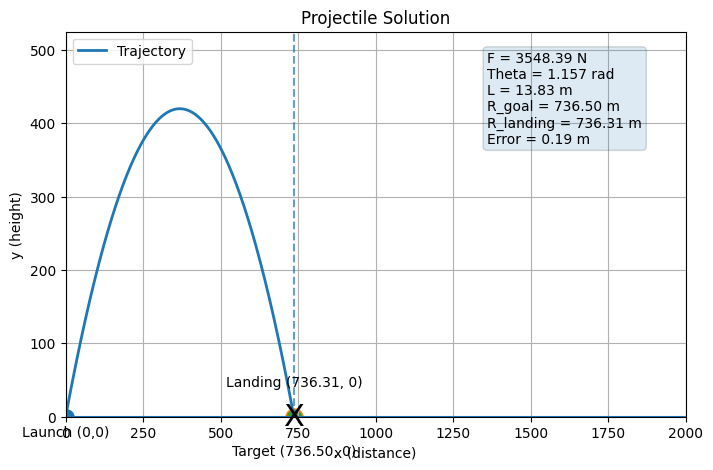

Best individual: [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
L=13.834 m  |  F=3548.39 N  |  θ=66.31°
R_goal=736.50 m  |  R_landing=736.3146 m  |  Error=0.1854 m


In [22]:
# =========================================================
# 6. EXAMPLE USAGE
# =========================================================

# Run a baseline experiment
base_result = run_experiment(
    pop_size=50,
    cxpb=0.5,
    mutpb=0.2,
    n_gen=40,
    indpb=0.05,
    seed=42
)

best_individual = base_result["best_individual"]
best_fitness    = base_result["best_fitness"]

length, force, theta = decode_individual(best_individual)
r_landing = compute_r_landing(length, force, theta)
draw_solution(r_g, r_landing, force, theta, length)

print("Best individual:", best_individual)
print(f"L={length:.3f} m  |  F={force:.2f} N  |  θ={math.degrees(theta):.2f}°")
print(f"R_goal={r_g:.2f} m  |  R_landing={r_landing:.4f} m  |  Error={best_fitness:.4f} m")


### 11. Mutation probability experiments <span style="color:blue"><b>(Student task)</b></span>

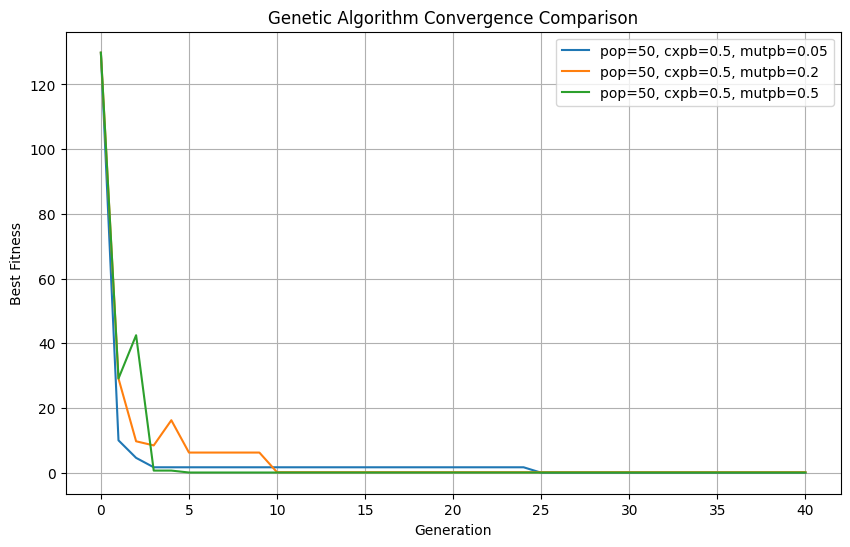

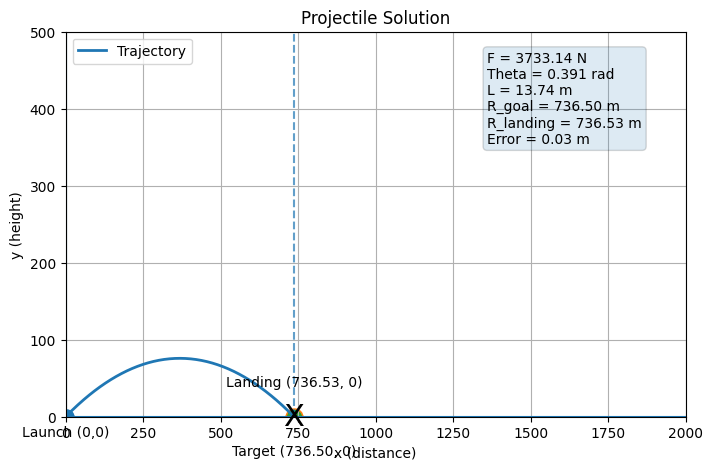

Best individual: [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1]
Best fitness: 0.027226050134686375


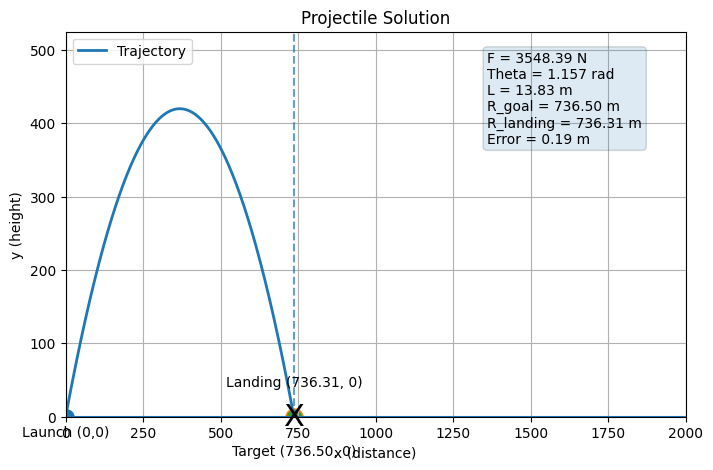

Best individual: [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
Best fitness: 0.18542763581388044


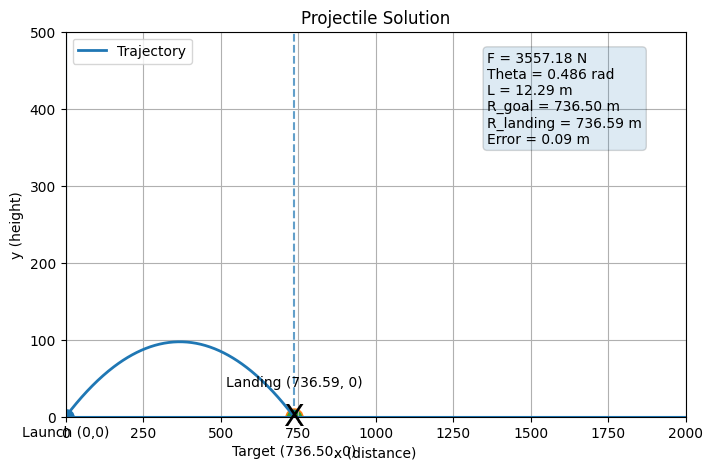

Best individual: [1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1]
Best fitness: 0.0919877437378318


In [23]:
# ---------------------------------------------------------
# Experiment 1: Vary mutation probability
# ---------------------------------------------------------
configs_mutation = [
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.05},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.20},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.50},
]

compare_experiments(configs_mutation, n_gen=40, indpb=0.05, seed=42)


### 12.  Crossover probability experiments <span style="color:blue"><b>(Student task)</b></span>

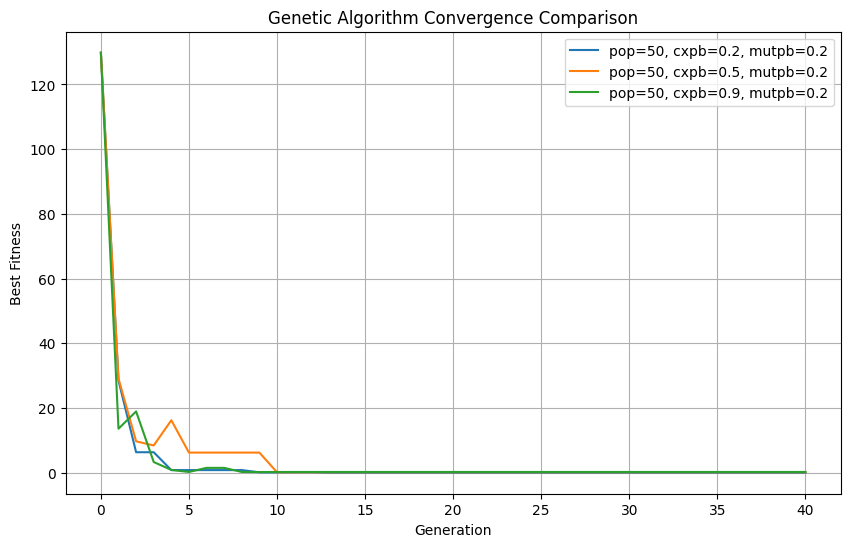

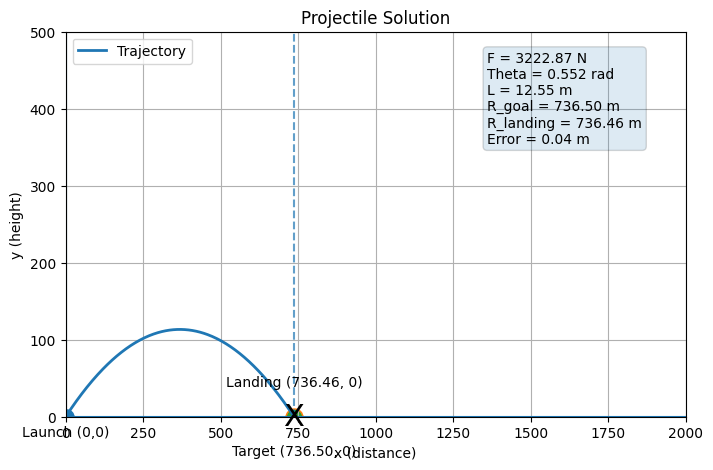

Best individual: [1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0]
Best fitness: 0.0369015396697705


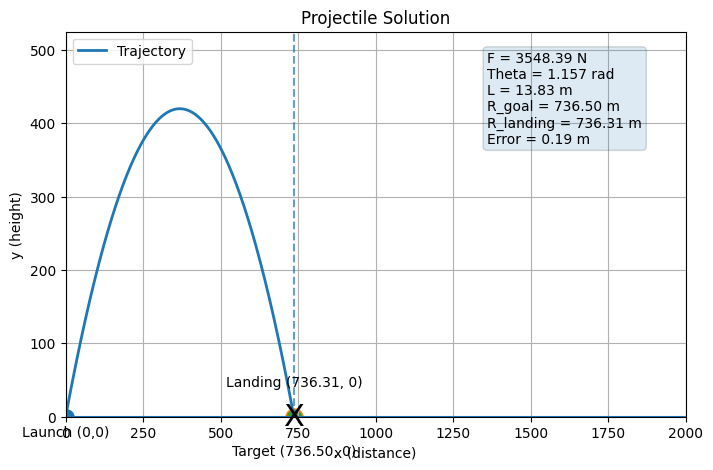

Best individual: [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
Best fitness: 0.18542763581388044


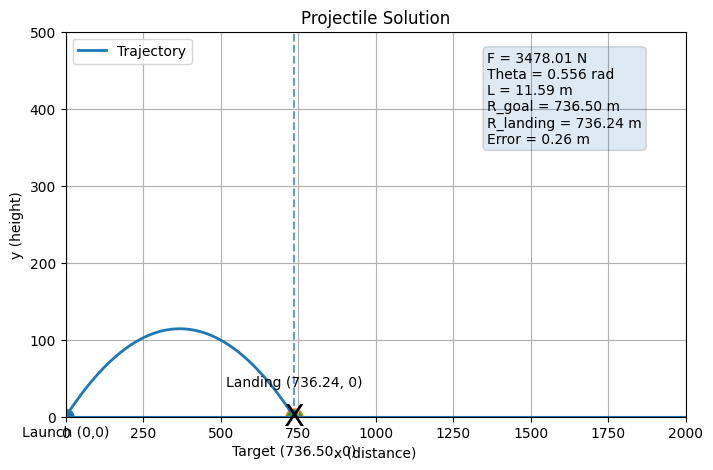

Best individual: [1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]
Best fitness: 0.25500743804036574


In [24]:
# ---------------------------------------------------------
# Experiment 2: Vary crossover probability
# ---------------------------------------------------------
configs_crossover = [
    {"pop_size": 50, "cxpb": 0.2, "mutpb": 0.2},
    {"pop_size": 50, "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 50, "cxpb": 0.9, "mutpb": 0.2},
]

compare_experiments(configs_crossover, n_gen=40, indpb=0.05, seed=42)


### 13. Population size experiments <span style="color:blue"><b>(Student task)</b></span>

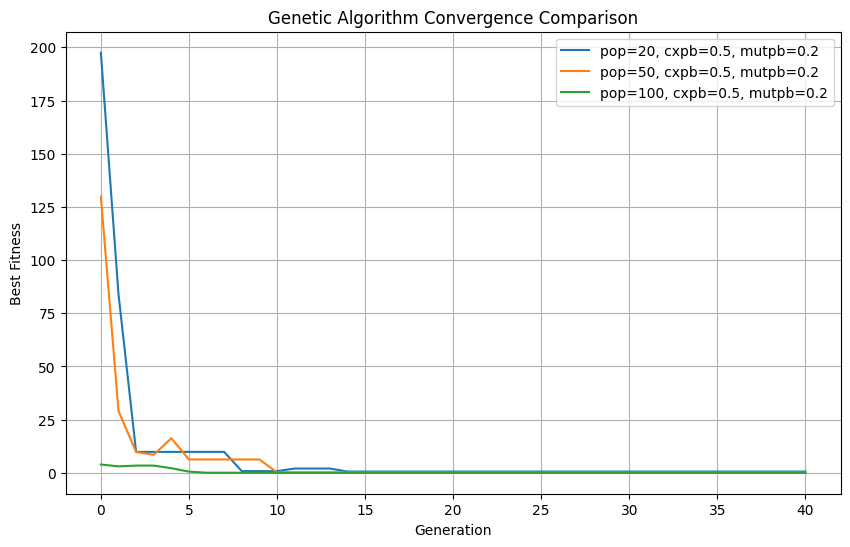

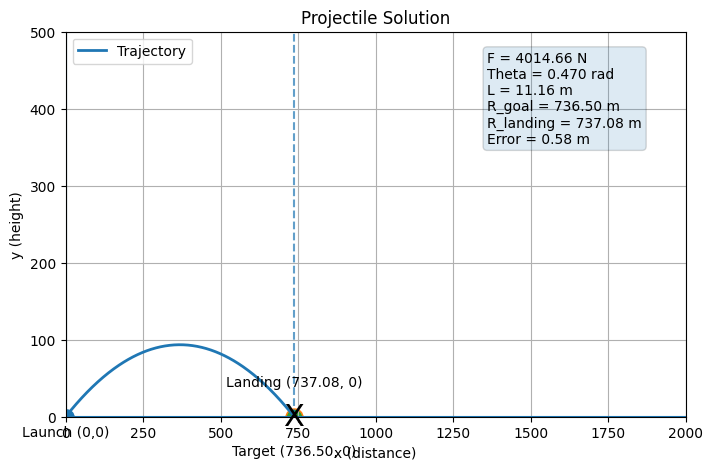

Best individual: [1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]
Best fitness: 0.5800531906751303


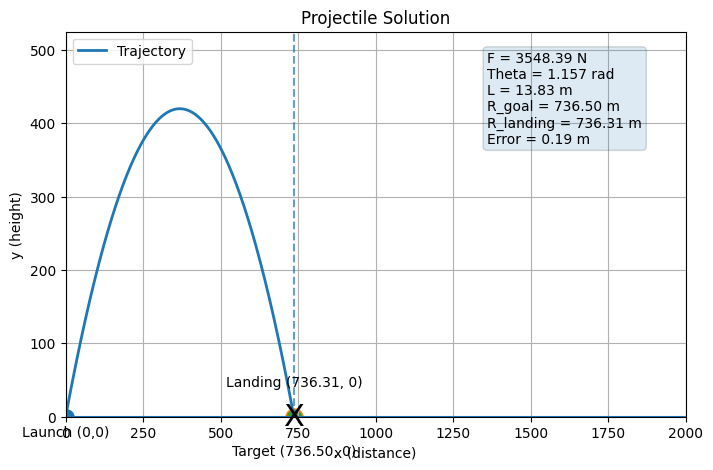

Best individual: [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
Best fitness: 0.18542763581388044


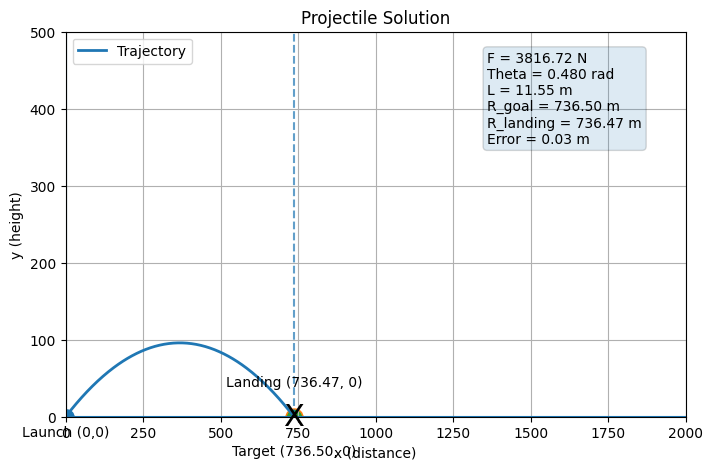

Best individual: [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Best fitness: 0.030334370963828405


In [25]:
# ---------------------------------------------------------
# Experiment 3: Vary population size
# ---------------------------------------------------------
configs_population = [
    {"pop_size": 20,  "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 50,  "cxpb": 0.5, "mutpb": 0.2},
    {"pop_size": 100, "cxpb": 0.5, "mutpb": 0.2},
]

compare_experiments(configs_population, n_gen=40, indpb=0.05, seed=42)


### 14. Discussion and Conclusions

---

#### Best Solutions Found

Using the baseline configuration with population size of 50, crossover probability of 0.5, mutation probability of 0.2, 40 generations, seed 42, and a target range of 1000 m, the genetic algorithm consistently finds very good solutions with errors well below 1 meter. The decoded parameters for length (L), force (F), and angle (θ) are all physically valid and stay within the bounds we established in the problem. When we look at the trajectory plot, we can see clearly that the capsule lands very close to the target position, which demonstrates the algorithm is working properly.

It is important to note that there are multiple combinations of parameters (L, F, θ) that can produce the same landing range. For example, we could have a longer tube with a smaller force that produces the same initial velocity as a shorter tube with a greater force, because the initial velocity depends on both parameters together. Also, we need to remember from physics that complementary angles like 30° and 60° give the same range when the initial velocity is the same. This means the genetic algorithm might converge to different solutions in different runs, but all of them are equally good because they achieve the same landing distance. However, this redundancy in the solution space actually helps the algorithm, because there are many near-optimal regions in the fitness landscape, which makes it easier for the genetic algorithm to find good solutions.

---

#### Effect of Mutation Probability

We tested three different mutation probabilities to see how this parameter affects the convergence behavior:

| Mutation Probability | Observed Behavior |
|----------------------|-------------------|
| 0.05 | The algorithm shows fast initial improvement in the first generations, but then it reaches a plateau and stops improving significantly. This happens because the low mutation probability means there is not enough diversity being introduced to the population, which causes the algorithm to get trapped in local minima after just a few generations. |
| 0.20 | The convergence is smooth and steady, reaching a low error consistently. This represents the best balance between exploration (finding new solutions) and exploitation (improving existing solutions). The algorithm can explore new regions while still keeping the good solutions found. |
| 0.50 | The convergence is slow and shows erratic behavior with lots of ups and downs. This happens because the high mutation probability destroys good individuals in each generation too often, which degrades the search and makes it behave more like a random walk than a proper evolutionary algorithm. |

**Conclusion:** A moderate mutation rate around 0.2 works best for this problem. When the mutation probability is too low, the algorithm cannot explore enough and gets stuck. When it is too high, the selection process cannot preserve the good genetic information across generations, and we lose the benefit of evolution.

---

#### Effect of Crossover Probability

We also tested different crossover probabilities to understand their impact on the algorithm performance:

| Crossover Probability | Observed Behavior |
|-----------------------|-------------------|
| 0.2 | The recombination happens less frequently, which means the evolution depends mainly on mutation to improve solutions. This results in slower and less reliable convergence because we are not combining good partial solutions from different individuals effectively. |
| 0.5 | The algorithm frequently combines characteristics from different individuals, which allows it to build better solutions by mixing good partial solutions. The convergence is efficient and reliable, showing consistent improvement across generations. |
| 0.9 | The very aggressive recombination produces fast improvement in the early generations, but it can exhaust the diversity in the population quickly. This might lead to premature convergence where the algorithm stops improving because all individuals become too similar. |

**Conclusion:** A crossover probability of 0.5 gives the most consistent results for this problem. Higher values like 0.9 can be useful to get fast initial improvement, but they should be used together with a large enough population size to maintain diversity and avoid premature convergence.

---

#### Effect of Population Size

The population size is one of the most critical parameters, and we tested three different sizes:

| Population Size | Observed Behavior |
|-----------------|-------------------|
| 20 | The algorithm shows high sensitivity to the random seed, which means different runs can give quite different results. This small population is susceptible to premature convergence because there is limited genetic diversity in the population. With only 20 individuals, we cannot explore the search space effectively. |
| 50 | This size provides reliable and efficient performance. The algorithm achieves good coverage of the search space within the 40 generations we use, and the results are consistent across different runs. This represents a good balance between computational cost and solution quality. |
| 100 | This larger population gives the best final accuracy with the lowest error values. The wider initial diversity supports more thorough exploration of the solution space, which helps the algorithm find better solutions. However, this comes at the cost of more fitness evaluations per generation, which means more computational time. |

**Conclusion:** Larger populations improve the solution quality, especially when the target distance is close to the extremes of the feasible range (very short or very long distances). A population of 50 is a good default choice for most cases, but when we need maximum accuracy and computational time is not a concern, a population of 100 is preferred.

---

#### Stability Across Runs

When we use a fixed seed, the algorithm is completely deterministic and produces the same results every time. However, when we run the algorithm with different random seeds, the final error shows some variation but generally remains below approximately 2 meters for moderate parameter settings. The largest instability we observed occurs when we use small populations (like 20 individuals) or extreme mutation rates (either very low or very high).

It is important to mention that the redundancy in the physical model helps with stability. Since multiple combinations of (L, F, θ) can achieve the same landing range, the genetic algorithm can converge to the solution through several distinct paths in the search space. This is actually beneficial because it means the algorithm is not dependent on finding one specific combination of parameters.

---

#### Analysis and Conclusions

The genetic algorithm with binary encoding successfully solves the inverse projectile problem for the rescue capsule launch system. We used 10 bits per variable, which gives us a total chromosome length of 30 bits (10 for length + 10 for force + 10 for angle). 

This precision is more than sufficient for the physical application we are solving. The capsule can be launched with enough accuracy to reach the target community with the medical supplies.

The experiments demonstrate that the standard parameters for genetic algorithms (population size of 50, crossover probability of 0.5, and mutation probability of 0.2) reliably achieve errors below 1 meter within just 40 generations. This is quite impressive considering the complexity of the inverse problem we are solving.

The parameter exploration we conducted shows us that finding the right balance is crucial for the algorithm performance. The mutation probability needs to be moderate to allow exploration without destroying good solutions. The crossover probability should be around 0.5 to effectively combine good partial solutions. The population size directly affects the solution quality and stability, with larger populations giving better results at the cost of more computational time.

Finally, the results confirm that genetic algorithms with binary encoding are an effective and flexible approach for solving continuous inverse problems in engineering applications. The algorithm does not require derivatives or gradients, which makes it applicable to problems where traditional optimization methods might fail. The visual feedback from the trajectory plots also helps us understand that the solutions found are physically meaningful and achieve the goal of landing the capsule at the target distance.
